In [5]:
import sys
sys.path.append('..')
from utils.filters import *
from utils.baseline_tools import *
import pickle
import numpy as np
from matplotlib.pyplot import cm
import pandas as pd
from numpy import linspace
from utils.display_tools import load_best_forecasts, display_predictions, display_predictions_2
from utils.data_processing_tools import full_preprocessing_pipeline, bring_to_original_range
from utils.general_tools import pd_to_param_holder
import functools as ft

import matplotlib.pyplot as plt
from utils.general_tools import results_to_pd, param_holder
from utils.modeling_tools import perform_modeling_sarimax, perform_modeling_varmax


In [6]:
data = pickle.load(open("../saves_and_results/cache_endog.p", "rb"))
exogs = pickle.load(open("../saves_and_results/cache_exogs.p", "rb"))

In [3]:
loc = "Lister"
direction = "asc0"
row_length = 2

In [36]:
combo = param_holder(
    p=3,
    d=0,
    q=0,
    f= 1,
    ex=[
        [],
        [],
    ],
    mean=[
        3,
        3,
    ],
    decompose=1,
    interaction=0,
    estimator=0,
    n_estimators=0,
    max_depth=0,
    learning_rate=0,
)

In [37]:
(train,
test,
max_data,
min_data,
trend,
seasonality,
test_trend,
test_seasonality) = (
full_preprocessing_pipeline(data[loc][direction], exogs[loc], combo, model_search=False)
)

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


In [38]:
test

[              720574    720593    720808    720906
 datetime                                          
 2020-01-02  0.548095  0.569994  0.556518  0.493766
 2020-01-08  0.531824  0.470951  0.587078  0.477192
 2020-01-14  0.560189  0.541366  0.599848  0.480500
 2020-01-20  0.441319  0.690391  0.516743  0.436321
 2020-01-26  0.443124  0.741920  0.572117  0.457396
 ...              ...       ...       ...       ...
 2020-12-03  0.494828  0.385606  0.490352  0.494312
 2020-12-09  0.538913  0.711495  0.498367  0.545558
 2020-12-15  0.628098  0.473912  0.590597  0.533964
 2020-12-21  0.106323  0.456587  0.471069  0.545915
 2020-12-27  0.470787  0.350148  0.585571  0.466506
 
 [61 rows x 4 columns],
             sin_order_1  cos_order_1  W_mean_3_0  T_mean_3_0
 date                                                        
 2020-01-02     0.021386     0.355382    0.850686    0.501950
 2020-01-08     0.009027     0.405473    0.854722    0.725785
 2020-01-14     0.001895     0.456570    0.871671 

In [39]:
train[1].min()

sin_order_1    0.0
cos_order_1    0.0
W_mean_3_0     0.0
T_mean_3_0     0.0
dtype: float64

<AxesSubplot:xlabel='date'>

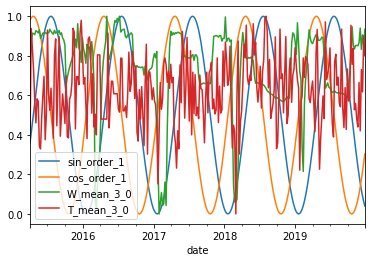

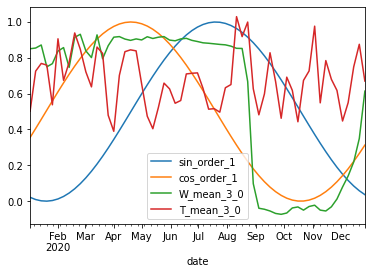

In [40]:
train[1].plot()
test[1].plot()

In [23]:
test[1].min()

sin_order_1    0.000065
cos_order_1    0.000663
W_0           -0.076739
dtype: float64

In [ ]:
# Runs quite a bit.
fc_stack = {}
model_stack = []
for model_type in ["sarimax"]: # var
    print(model_type)
    preds = []
    for ind in ms[model_type]["Index"]:
        combo = pd_to_param_holder(ms[model_type], ind)
        (train,
        test,
        max_data,
        min_data,
        trend,
        seasonality,
        test_trend,
        test_seasonality) = (
        full_preprocessing_pipeline(data[loc][direction], exogs[loc], combo, model_search=False)
        )

        
        if model_type == "sarimax":
            model = perform_modeling_sarimax(train[0][str(ind)], train[1], combo)

            if len(test[1].columns) != 0:
                append_model = model.append(test[0][str(ind)], refit=False, exog=test[1])
            else:
                append_model = model.append(test[0][str(ind)], refit=False)

            pred_one_step = append_model.predict(start=test[0].index[0])
            pred_one_step = pd.DataFrame(pred_one_step)
            pred_one_step.columns = [str(ind)]

            
            model_stack.append(append_model)
            
            # model = perform_modeling_varmax(train[0], train[1], combo)
            # if len(test[1].columns) != 0:
            #     append_res = model.append(test[0], refit=False, exog=test[1])
            # else:
            #     append_res = model.append(test[0], refit=False)
            # pred = append_res.predict(start=test[0].index[0])
            # pred.columns = test[0].columns
            # pred = pd.DataFrame(pred[str(ind)])
            # pred.columns = [0]


        # Transform to original range and appends results
        Y, Y_hat = bring_to_original_range(
            test[0][str(ind)],
            pred_one_step[str(ind)],
            max_data[str(ind)],
            min_data[str(ind)],
            (test_trend[str(ind)] if isinstance(trend, pd.DataFrame) else None),
            (test_seasonality[str(ind)] if isinstance(seasonality, pd.DataFrame) else None),
            data[loc][direction],
            str(ind),
        )
        preds.append(Y_hat)
    preds = pd.concat(preds, axis=1)
    #preds.columns = ms[model_type]["Index"].values
    fc_stack[model_type] = preds